## King Country - Bil Gatesin Komsularinin Ev fiyatlarini tahmin eden bir model kurma

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv('kc_house_data.csv')

In [29]:
df.tail()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,3,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,3,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,3,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,3,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287
21612,1523300157,20141015T000000,325000.0,2,0.75,1020,1076,2.0,0,0,3,7,1020,0,2008,0,98144,47.5941,-122.299,1020,1357


In [4]:
df.corr(numeric_only=True)

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
id,1.000000,-0.016762,0.001286,0.005160,-0.012258,-0.132109,0.018525,-0.002721,0.011592,-0.023783,0.008130,-0.010842,-0.005151,0.021380,-0.016907,-0.008224,-0.001891,0.020799,-0.002901,-0.138798
price,-0.016762,1.000000,0.308350,0.525138,0.702035,0.089661,0.256794,0.266369,0.397293,0.036362,0.667434,0.605567,0.323816,0.054012,0.126434,-0.053203,0.307003,0.021626,0.585379,0.082447
bedrooms,0.001286,0.308350,1.000000,0.515884,0.576671,0.031703,0.175429,-0.006582,0.079532,0.028472,0.356967,0.477600,0.303093,0.154178,0.018841,-0.152668,-0.008931,0.129473,0.391638,0.029244
bathrooms,0.005160,0.525138,0.515884,1.000000,0.754665,0.087740,0.500653,0.063744,0.187737,-0.124982,0.664983,0.685342,0.283770,0.506019,0.050739,-0.203866,0.024573,0.223042,0.568634,0.087175
sqft_living,-0.012258,0.702035,0.576671,0.754665,1.000000,0.172826,0.353949,0.103818,0.284611,-0.058753,0.762704,0.876597,0.435043,0.318049,0.055363,-0.199430,0.052529,0.240223,0.756420,0.183286
sqft_lot,-0.132109,0.089661,0.031703,0.087740,0.172826,1.000000,-0.005201,0.021604,0.074710,-0.008958,0.113621,0.183512,0.015286,0.053080,0.007644,-0.129574,-0.085683,0.229521,0.144608,0.718557
floors,0.018525,0.256794,0.175429,0.500653,0.353949,-0.005201,1.000000,0.023698,0.029444,-0.263768,0.458183,0.523885,-0.245705,0.489319,0.006338,-0.059121,0.049614,0.125419,0.279885,-0.011269
waterfront,-0.002721,0.266369,-0.006582,0.063744,0.103818,0.021604,0.023698,1.000000,0.401857,0.016653,0.082775,0.072075,0.080588,-0.026161,0.092885,0.030285,-0.014274,-0.041910,0.086463,0.030703
view,0.011592,0.397293,0.079532,0.187737,0.284611,0.074710,0.029444,0.401857,1.000000,0.045990,0.251321,0.167649,0.276947,-0.053440,0.103917,0.084827,0.006157,-0.078400,0.280439,0.072575
condition,-0.023783,0.036362,0.028472,-0.124982,-0.058753,-0.008958,-0.263768,0.016653,0.045990,1.000000,-0.144674,-0.158214,0.174105,-0.361417,-0.060618,0.003026,-0.014941,-0.106500,-0.092824,-0.003406


In [6]:
abs(df.corr(numeric_only=True)['price'].sort_values(ascending=False)) # price ile en cok korelasyon olan sutunlar

price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
id               0.016762
zipcode          0.053203
Name: price, dtype: float64

In [14]:
x = df[['sqft_living', 'grade', 'sqft_above', 'bathrooms', 'sqft_living15','view','sqft_basement','bedrooms','zipcode']]
x.head()

,sqft_living,grade,sqft_above,bathrooms,sqft_living15,view,sqft_basement,bedrooms,zipcode
0,1180,7,1180,1.00,1340,0,0,3,98178
1,2570,7,2170,2.25,1690,0,400,3,98125
2,770,6,770,1.00,2720,0,0,2,98028
3,1960,7,1050,3.00,1360,0,910,4,98136
4,1680,8,1680,2.00,1800,0,0,3,98074


In [15]:
y = df['price']
y.head()

0    221900.0
1    538000.0
2    180000.0
3    604000.0
4    510000.0
Name: price, dtype: float64

In [21]:
import scipy.stats as stats


for col in x.columns:
    # stats modülünün altındaki ttest_ind fonksiyonunu çağırıyoruz
    stat, p = stats.ttest_ind(x[col], y, nan_policy='omit')
    print(f"{col}: p-value = {p : .4e}")


sqft_living: p-value =  0.0000e+00
grade: p-value =  0.0000e+00
sqft_above: p-value =  0.0000e+00
bathrooms: p-value =  0.0000e+00
sqft_living15: p-value =  0.0000e+00
view: p-value =  0.0000e+00
sqft_basement: p-value =  0.0000e+00
bedrooms: p-value =  0.0000e+00
zipcode: p-value =  0.0000e+00


In [20]:
import statsmodels.api as sm

# statsmodels'in sabit terimi (intercept) hesaplaması için X'e sabit ekliyoruz
X_reg = sm.add_constant(x)

# Modeli kuruyoruz (y = ev fiyatı, X_reg = tüm özellikler)
model = sm.OLS(y, X_reg).fit()

# Tüm değişkenlerin p-değerlerini ve katsayılarını tek seferde görelim
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.584
Model:                            OLS   Adj. R-squared:                  0.584
Method:                 Least Squares   F-statistic:                     3789.
Date:                Thu, 21 May 2026   Prob (F-statistic):               0.00
Time:                        06:30:17   Log-Likelihood:            -2.9813e+05
No. Observations:               21613   AIC:                         5.963e+05
Df Residuals:                   21604   BIC:                         5.964e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -4.487e+07   3.16e+06    -14.190

In [22]:
x = df[['sqft_living', 'grade', 'sqft_above','view','sqft_basement','zipcode']]

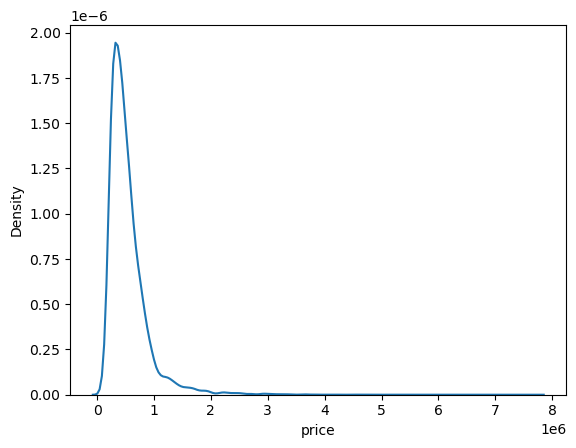

In [24]:
sns.kdeplot(df['price'], );

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",100)

from sklearn.linear_model import LinearRegression,SGDRegressor,Ridge,Lasso,ElasticNet
from sklearn.neighbors import KNeighborsRegressor, RadiusNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor,AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree, ExtraTreeRegressor
#pip install xgboost
from xgboost import XGBRegressor
from sklearn.svm import SVR

from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

def algo_test(x,y):
        #Bütün modelleri tanımlıyorum
        L=LinearRegression()
        R=Ridge()
        Lass=Lasso()
        E=ElasticNet()
        sgd=SGDRegressor()
        ETR=ExtraTreeRegressor()
        GBR=GradientBoostingRegressor()
        kn=KNeighborsRegressor()
        rkn=RadiusNeighborsRegressor(radius=1.0)
        ada=AdaBoostRegressor()
        dt=DecisionTreeRegressor()
        xgb=XGBRegressor()
        svr=SVR()
        mlp_regressor = MLPRegressor()

       
        
        algos=[L,R,Lass,E,sgd,ETR,GBR,ada,kn,dt,xgb,svr,mlp_regressor]
        algo_names=['Linear','Ridge','Lasso','ElasticNet','SGD','Extra Tree','Gradient Boosting',
                    'KNeighborsRegressor','AdaBoost','Decision Tree','XGBRegressor','SVR','mlp_regressor']
        x=MinMaxScaler().fit_transform(x)
        x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=.20,random_state=42)
        
        r_squared= []
        rmse= []
        mae= []
        
        #Hata ve doğruluk oranlarını bir tablo haline getirmek için bir dataframe oluşturuyorum
        result=pd.DataFrame(columns=['R_Squared','RMSE','MAE'],index=algo_names)
        
        
        for algo in algos:
            p=algo.fit(x_train,y_train).predict(x_test)
            r_squared.append(r2_score(y_test,p))
            rmse.append(mean_squared_error(y_test,p)**.5)
            mae.append(mean_absolute_error(y_test,p))
        
            

        #result adlı tabloya doğruluk ve hata oranlarımı yerleştiriyorum
        result.R_Squared=r_squared
        result.RMSE=rmse
        result.MAE=mae
        
       #oluşturduğum result tablosunu doğruluk oranına (r2_score) göre sıralayıp dönüyor
        rtable=result.sort_values('R_Squared',ascending=False)
        return rtable

In [28]:
algo_test(x,y)

,R_Squared,RMSE,MAE
XGBRegressor,0.797681,174888.335465,86031.161610
Gradient Boosting,0.757478,191477.667333,102596.718372
AdaBoost,0.660612,226511.664847,117168.218830
Decision Tree,0.644350,231874.962854,116647.144004
Lasso,0.580314,251886.515291,159438.989018
Ridge,0.580252,251904.849680,159308.835184
Linear,0.580186,251924.792062,159211.626666
SGD,0.579217,252215.468864,158892.404495
Extra Tree,0.497514,275616.044562,145349.757352
KNeighborsRegressor,0.469868,283096.493135,201505.214889


In [51]:
import numpy as np
import pandas as pd


df_processed = df.copy()

#Evin Yaşını Hesaplama (Şu anki yıldan yapım yılını çıkarıyoruz)
current_year = 2026  # İçinde bulunduğumuz yıl
df_processed['house_age'] = current_year - df_processed['yr_built']

#Tadilat Görmüş mü? (Gördüyse 1, görmediyse 0)
df_processed['is_renovated'] = df_processed['yr_renovated'].apply(lambda x: 1 if x > 0 else 0)

#Posta Koduna (Zipcode) Göre Ortalama Fiyat (Target Encoding)
# Bilgisayar posta kodunu düz sayı sanmasın diye, o bölgenin lükslük derecesiyle değiştiriyoruz
zip_price_map = df_processed.groupby('zipcode')['price'].mean()
df_processed['zip_avg_price'] = df_processed['zipcode'].map(zip_price_map)

# Tarih sutununu yıl-ay-gün formatına çevirmemiz lazım, çünkü şu anki haliyle metin (object) formatında ve modelimiz bunu anlayamadigindan sorun cikartiyor.!!!
# Tarih metnini gerçek tarih formatına çeviriyoruz
df_processed['date'] = pd.to_datetime(df_processed['date'])

# Tarihten "Satış Yılı" ve "Satış Ayı" adında iki tane sayısal sütun üretiyoruz
df_processed['sale_year'] = df_processed['date'].dt.year
df_processed['sale_month'] = df_processed['date'].dt.month

# orijinal metin sütununu siliyoruz, çünkü artık ona ihtiyacımız yok ve modelimizin kafasını karıştırabilir
df_processed = df_processed.drop(columns=['yr_built', 'yr_renovated', 'zipcode', 'date'])


In [52]:
# Bağımsız değişkenler (X) ve Hedef değişken (y) ayrımı
X = df_processed.drop(columns=['price'])
y = df_processed['price']


In [55]:
algo_test(X, y)

,R_Squared,RMSE,MAE
Gradient Boosting,0.870427,139958.367861,76884.149566
XGBRegressor,0.868790,140840.030472,69613.943782
Lasso,0.789060,178575.549291,103299.977146
Linear,0.789057,178576.757569,103300.808767
Ridge,0.788734,178713.611656,103012.327867
SGD,0.785664,180007.338104,103146.776473
AdaBoost,0.767473,187490.472362,98260.571177
Decision Tree,0.728509,202590.831232,101511.974555
Extra Tree,0.671483,222854.592787,108739.449456
KNeighborsRegressor,0.458428,286134.694480,246230.781518


In [ ]:
# Fiyatın logaritmasını alıyoruz
# Fiyat dağılımı genellikle sağa çarpık olduğu için, logaritmasını almak dağılımı daha normal hale getirebilir ve modelin performansını artırabilir.
y_log = np.log1p(y)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

In [59]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(random_state=42)

# Modeli yeni zenginleştirilmiş ve logaritmik verimizle eğitiyoruz
xgb_model.fit(X_train, y_train_log)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [60]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Test verisiyle logaritmik tahmin alıyoruz
log_predictions =xgb_model.predict(X_test)

# Tahminleri ve gerçek test değerlerini normal fiyat birimine (Dolar/TL) geri döndürüyoruz
real_predictions = np.expm1(log_predictions)
real_y_test = np.expm1(y_test_log)


r2_score(real_y_test, real_predictions)

0.905194960108194